# Load data and libraries

In [1]:
!pip install sympy==1.12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 59.3 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cud

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Mount Google Drive (for Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    in_colab = True
except:
    in_colab = False

#unzip data
!unzip "/content/drive/My Drive/Mental Health Recommendation Module/Data Sets/FER2013.zip" -d /content/

# Paths
DATA_DIR = "/content/train" if in_colab else "./train"
SAVE_PATH = "/content/drive/My Drive/Mental Health Recommendation Module/Models/DLModel.pkl" if in_colab else "./DLModel.pkl"

# Settings
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 50
SEED = 42
POSITIVE_CLASSES = ['happy', 'neutral']

# Seed for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


Streaming output truncated to the last 5000 lines.
  inflating: /content/train/sad/Training_65242339.jpg  
  inflating: /content/train/sad/Training_65267116.jpg  
  inflating: /content/train/sad/Training_65275626.jpg  
  inflating: /content/train/sad/Training_6529266.jpg  
  inflating: /content/train/sad/Training_65329617.jpg  
  inflating: /content/train/sad/Training_65338712.jpg  
  inflating: /content/train/sad/Training_65338797.jpg  
  inflating: /content/train/sad/Training_65387162.jpg  
  inflating: /content/train/sad/Training_65404494.jpg  
  inflating: /content/train/sad/Training_65426218.jpg  
  inflating: /content/train/sad/Training_65430136.jpg  
  inflating: /content/train/sad/Training_65437377.jpg  
  inflating: /content/train/sad/Training_6545735.jpg  
  inflating: /content/train/sad/Training_65463385.jpg  
  inflating: /content/train/sad/Training_65473985.jpg  
  inflating: /content/train/sad/Training_65502829.jpg  
  inflating: /content/train/sad/Training_65505359.jpg  

# Data preprocessing

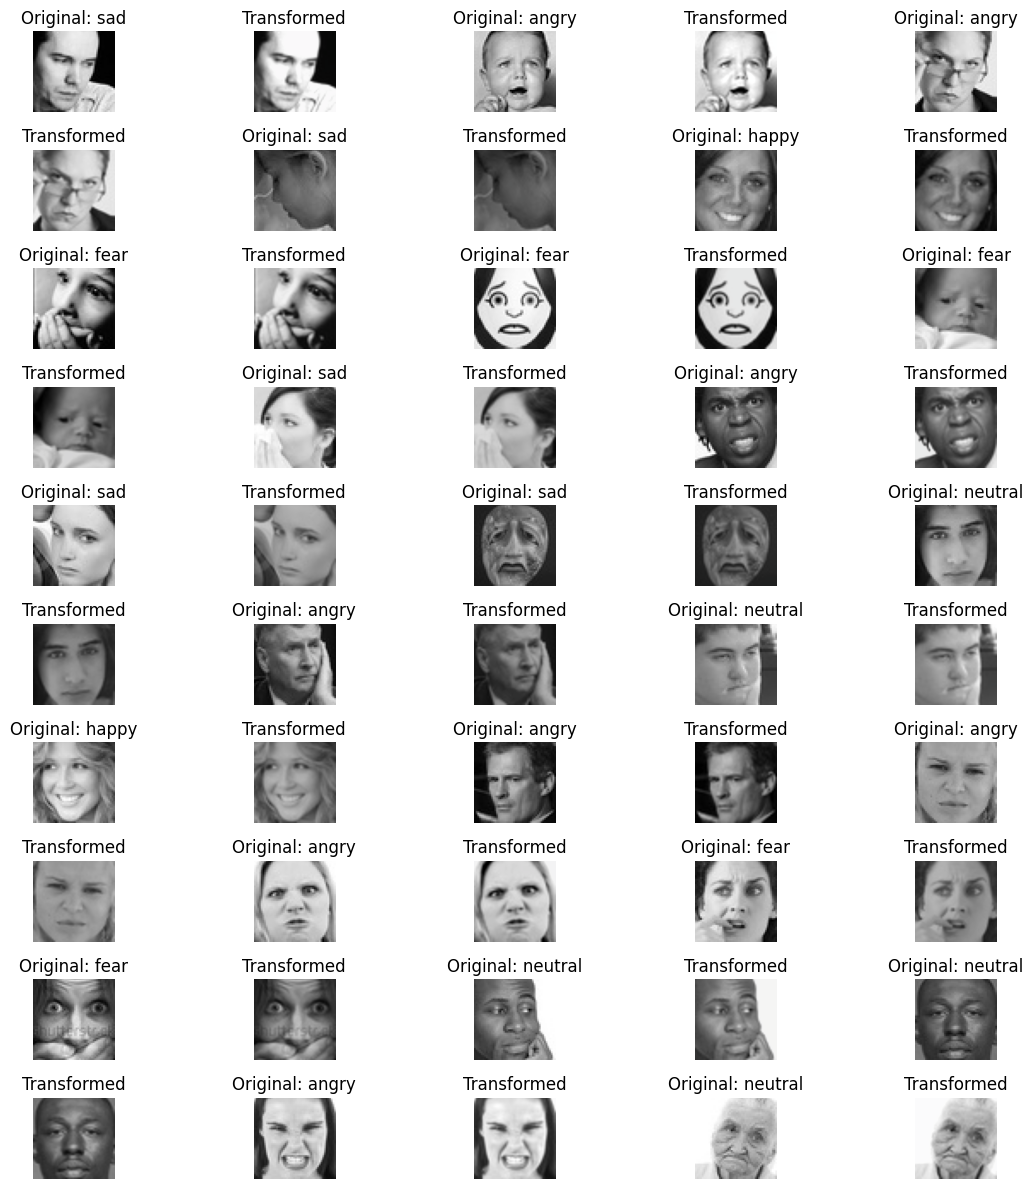

In [3]:
# Transform with augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets (original for display, transformed for training)
dataset_original = ImageFolder(DATA_DIR)
dataset_transformed = ImageFolder(DATA_DIR, transform=transform)

# Show 25 before & after transformation images
def denormalize(tensor_img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor_img.permute(1, 2, 0).numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

def show_transforms(original_ds, transformed_ds, count=25):
    indices = random.sample(range(len(original_ds)), count)
    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(indices):
        # Original
        original_img, label = original_ds[idx]
        plt.subplot(10, 5, 2*i + 1)
        plt.imshow(original_img)
        plt.title(f"Original: {original_ds.classes[label]}")
        plt.axis("off")

        # Transformed
        transformed_img, _ = transformed_ds[idx]
        transformed_img = denormalize(transformed_img)
        plt.subplot(10, 5, 2*i + 2)
        plt.imshow(transformed_img)
        plt.title("Transformed")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Show transformations
show_transforms(dataset_original, dataset_transformed)

# Binary labeling wrapper
class BinaryEmotionDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, positive_classes):
        self.dataset = dataset
        self.positive_indices = [dataset.class_to_idx[c] for c in positive_classes]

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        binary_label = 1 if label in self.positive_indices else 0
        return image, torch.tensor(binary_label, dtype=torch.float32)

    def __len__(self):
        return len(self.dataset)

# Wrap and split data
binary_dataset = BinaryEmotionDataset(dataset_transformed, POSITIVE_CLASSES)
train_size = int(0.8 * len(binary_dataset))
val_size = len(binary_dataset) - train_size
train_set, val_set = random_split(binary_dataset, [train_size, val_size])
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE)


# model Training and validation

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:01<00:00, 79.0MB/s]


Epoch 1/50 - Train Loss: 0.4335, Accuracy: 79.28%, Val Loss: 0.3587
Epoch 2/50 - Train Loss: 0.3124, Accuracy: 86.57%, Val Loss: 0.3449
Epoch 3/50 - Train Loss: 0.2302, Accuracy: 90.36%, Val Loss: 0.3578
Epoch 4/50 - Train Loss: 0.1619, Accuracy: 93.44%, Val Loss: 0.3971
Epoch 5/50 - Train Loss: 0.1035, Accuracy: 96.06%, Val Loss: 0.4326
Early stopping triggered at epoch 5

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.95      0.88      3302
    Positive       0.91      0.70      0.79      2440

    accuracy                           0.84      5742
   macro avg       0.86      0.83      0.83      5742
weighted avg       0.85      0.84      0.84      5742



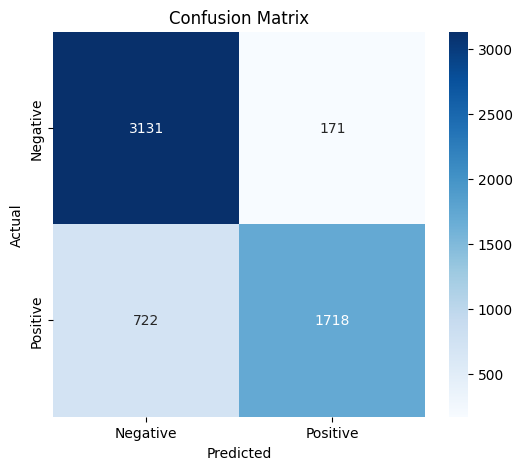

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.convnext_tiny(pretrained=True)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0

# Training loop with early stopping
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load(SAVE_PATH))

# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = torch.sigmoid(outputs) > 0.5
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().astype(int))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
